# Customer Segmentation Analysis

### Libraries

In [221]:
!pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

### 1. Data Loading and Preprocessing

In [222]:
df = pd.read_csv(r"C:\Users\sebas\OneDrive\Ambiente de Trabalho\customer-segmentation-analysis\data\Mall_Customers.csv")

In [223]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [224]:
df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [225]:
df.rename(columns={'Annual Income (k$)': 'Annual Income'}, inplace=True)

In [226]:
df.rename(columns={'Spending Score (1-100)': 'Spending Score'}, inplace=True)

In [227]:
df.rename(columns={'Genre': 'Gender'}, inplace=True)

In [228]:
df = df.drop('CustomerID', axis=1)

Categoric Variables

In [229]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

Numeric variables

In [230]:
df.describe()

,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


Important notes
- Age ranges between 18 and 70 years old.
- Annual income of the customers range between 15k and 137k. | std = 26
- Mall atributed scores from 1 to 100 to the custoners, based on their spending levels.
- Females > Males

### 2. Exploratory Data Analysis

#### 2.1. Outliers
- No outliers found except for Annual Income.

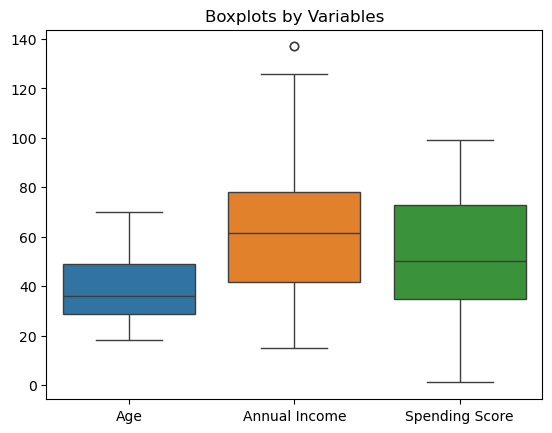

In [231]:
sns.boxplot(df)
plt.title("Boxplots by Variables")
plt.show()

##### - Log transformation
- In this case not so effective, best approach could be identifying and removing outliers by boxplots.

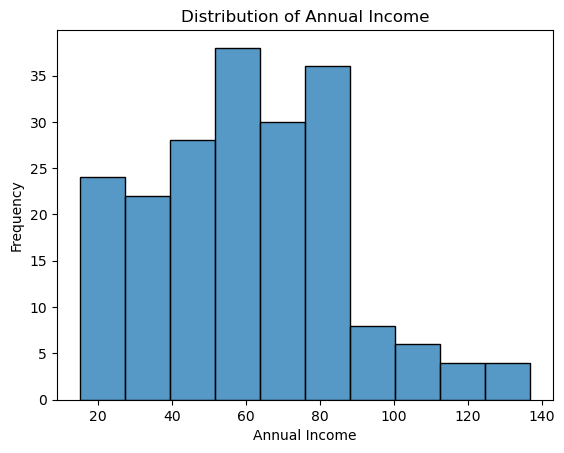

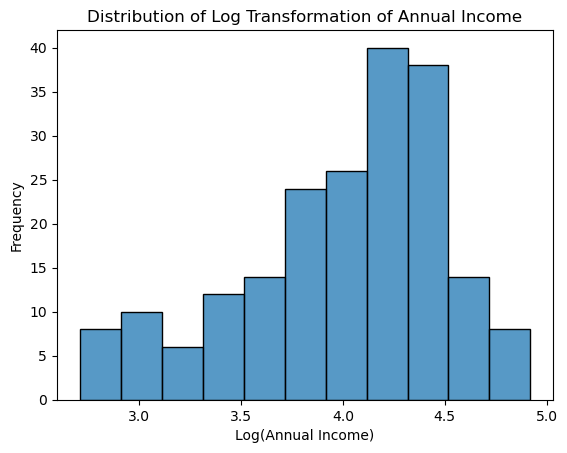

In [232]:
sns.histplot(df['Annual Income'])
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.show()
sns.histplot(np.log(df['Annual Income']))
plt.title('Distribution of Log Transformation of Annual Income')
plt.xlabel('Log(Annual Income)')
plt.ylabel('Frequency')
plt.show()

In [233]:
Q1 = df['Annual Income'].quantile(0.25)
Q3 = df['Annual Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Annual Income'] < lower) | (df['Annual Income'] > upper)]
outliers

,Gender,Age,Annual Income,Spending Score
198,Male,32,137,18
199,Male,30,137,83


In [234]:
df_clean = df[(df['Annual Income'] >= lower) & (df['Annual Income'] <= upper)]

In [235]:
df.shape
df_clean.shape

(198, 4)

#### 2.2. Distributions Analysis of Categoric Variables

To better understand the behavioral patterns, we decide to group age, income, and spending score into categoric variables. 
This variables won't be used in modelling, but will be essential to EDA and to define the final segments.

In [236]:
bins = [18, 25, 35, 45, 55, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '56-70']
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, include_lowest=True)

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\3257566111.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, include_lowest=True)


In [237]:
bins   = [15, 40, 70, 100, 145]
labels = ['Low', 'Medium', 'High', 'Very High']

df_clean['IncomeGroup'] = pd.cut(df_clean['Annual Income'], bins=bins, labels=labels, include_lowest=True)

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\299530557.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['IncomeGroup'] = pd.cut(df_clean['Annual Income'], bins=bins, labels=labels, include_lowest=True)


In [238]:
df_clean['SpendingGroup'] = pd.cut(df_clean['Spending Score'], bins=[0, 25, 50, 75, 100], labels=['Very Low','Low','High','Very High'], include_lowest=True)

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\1990786908.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['SpendingGroup'] = pd.cut(df_clean['Spending Score'], bins=[0, 25, 50, 75, 100], labels=['Very Low','Low','High','Very High'], include_lowest=True)


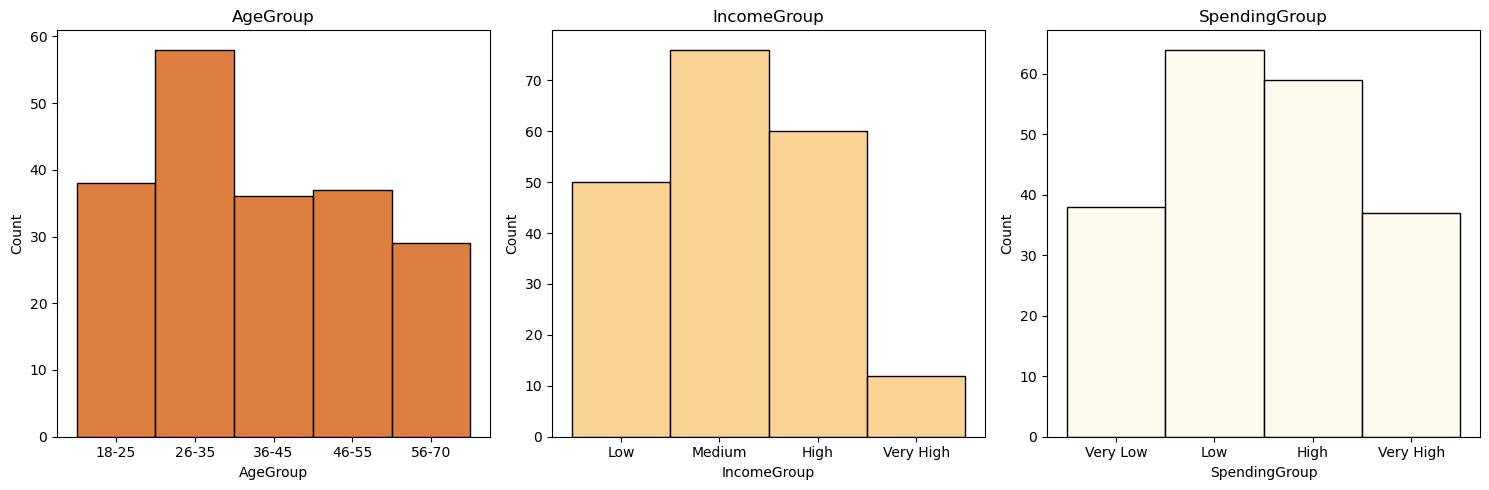

In [239]:
cols = ['AgeGroup', 'IncomeGroup', 'SpendingGroup']
colors = ["#D35400", "#F8C471", "#FEF9E7"]

fig, axes = plt.subplots(1, len(cols), figsize=(15, 5))

for i, col in enumerate(cols):
    sns.histplot(df_clean[col], ax=axes[i], color=colors[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\2645079637.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_means = df_clean.groupby('AgeGroup')['Annual Income'].mean().reindex(age_order)
C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\2645079637.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spend_means  = df_clean.groupby('AgeGroup')['Spending Score'].mean().reindex(age_order)
C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\2645079637.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `l

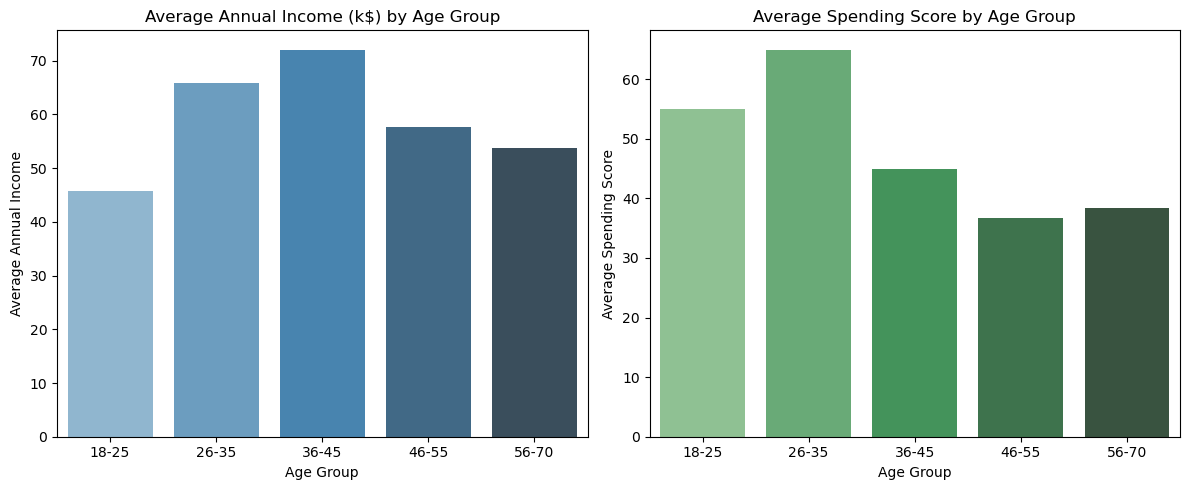

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

age_order = ['18-25', '26-35', '36-45', '46-55', '56-70']
income_means = df_clean.groupby('AgeGroup')['Annual Income'].mean().reindex(age_order)
spend_means  = df_clean.groupby('AgeGroup')['Spending Score'].mean().reindex(age_order)

#For the Annual Income
sns.barplot(x=income_means.index, y=income_means.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Average Annual Income (k$) by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Annual Income')

#For the Spending Score
sns.barplot(x=spend_means.index, y=spend_means.values, ax=axes[1], palette='Greens_d')
axes[1].set_title('Average Spending Score by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Spending Score')

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

- As expected, customers between the ages 26-35 and 36-45 own higher income levels. 

- However, by the 2nd graph only spending score of the age group 26-35 is in accordance with the high income level. 

    -- High annual income -> High Spending Score

- Young adults tend to spend more, despite having lower income levels. 

- Opportunity to retain customers from 36 to 70 since they have a higher income power and do not spend that much.

In [241]:
df_clean.groupby('AgeGroup')['Spending Score'].mean() 

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\1872160281.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('AgeGroup')['Spending Score'].mean()


AgeGroup
18-25    54.947368
26-35    64.931034
36-45    44.833333
46-55    36.702703
56-70    38.379310
Name: Spending Score, dtype: float64

In [242]:
#df.groupby(['AgeGroup', 'IncomeGroup']).size()

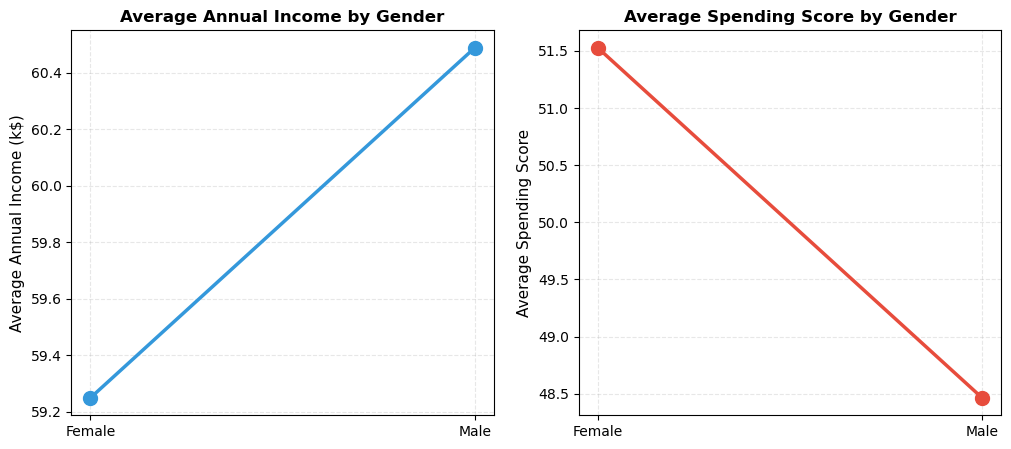

In [243]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

grouped_income = df_clean.groupby('Gender')['Annual Income'].mean()
grouped_spending = df_clean.groupby('Gender')['Spending Score'].mean()

# Income
axes[0].plot(grouped_income.index, grouped_income.values, marker='o', color='#3498db', linewidth=2.5, markersize=10)
axes[0].set_title('Average Annual Income by Gender', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Annual Income (k$)', fontsize=11)
axes[0].grid(alpha=0.3, linestyle='--')

# Spending Score
axes[1].plot(grouped_spending.index, grouped_spending.values, marker='o', color='#e74c3c', linewidth=2.5, markersize=10)
axes[1].set_title('Average Spending Score by Gender', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Spending Score', fontsize=11)
axes[1].grid(alpha=0.3, linestyle='--')

plt.show()

**Expected behavior**: *Higher Average Annual Income -> Higher Spending Score*

**Reality**: 
- Average Annual Income is higher in males, but Spending Score lower.
- Average Annual Income is lower in females, but Spending Score is higher.

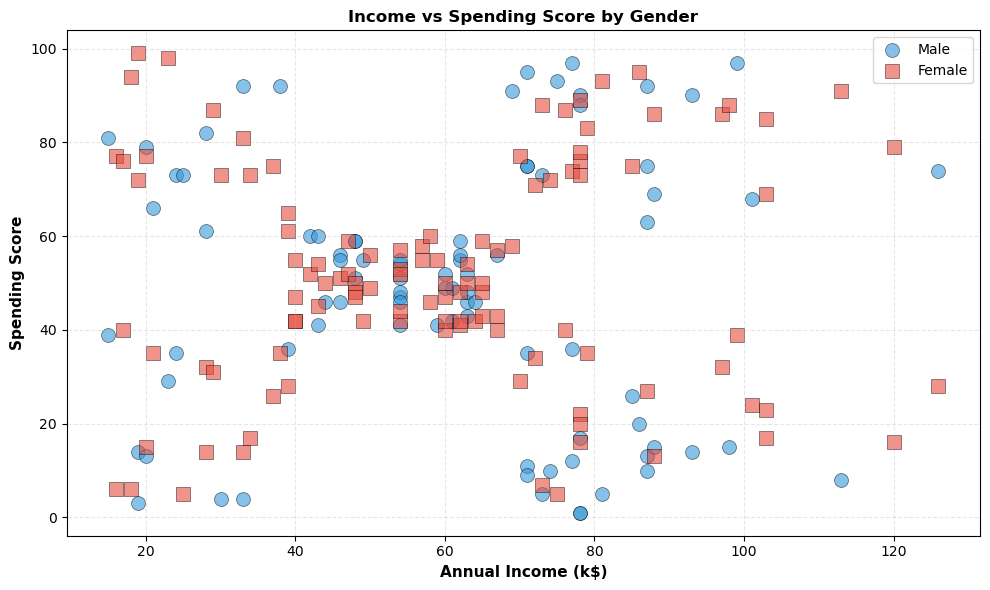

In [244]:
markers = {"Male": "o", "Female": "s"}
colors = {"Male": "#3498db", "Female": "#e74c3c"}

plt.figure(figsize=(10, 6))

for gender, marker in markers.items():
    subset = df_clean[df_clean['Gender'] == gender]
    plt.scatter(subset['Annual Income'],
                subset['Spending Score'],
                label=gender,
                marker=marker,
                s=100,
                alpha=0.6,
                color=colors[gender],
                edgecolors='black',
                linewidth=0.5)

plt.xlabel('Annual Income (k$)', fontsize=11, fontweight='bold')
plt.ylabel('Spending Score', fontsize=11, fontweight='bold')
plt.title('Income vs Spending Score by Gender', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### Insights 

Through a first analysis in **1. Data Loading and Preprocessing** it was possible to state that:
- Ages range bewteen 18y and 70y;
- Annual Income range between 15k and 137k;
- Attributed spending score to the customers is from 1 and 100.
- Mall customers are mainly composed by females.

Diving deeper into **2. EDA**:

**2.1. Outliers**

- Outliers found for *Annual Income*. *Annual Income* presented a right sweked distribution, and log-transformation was applied to correct it. As this was not effective as expective, decided to remove those outliers since it would not have a big impact on the size of our data set.

**2.2. Distribution Analysis of Categoric Variables**

- Adding Categoric Variables: To better understand the behavioral patterns, we decide to group *Age*, *Annual Income*, and *Spending Score* into categoric variables. This variables won't be used in modelling, but were essential to EDA.

- Majority of the mall customers are 2) within the 26-35 age group, 3) own high income levels, 4) have low to high spending scores.

- As expected, customers between the ages 26-35 and 36-45 own higher *Annual Income* levels. 

- However, it was expected that:

    **High Annual Income -> High Spending Score**

    **Reality:**
    
    - Only *Spending Score* of the age group 26-35 is in accordance with the high income level of that group. 
    - Young adults (18-26) tend to spend more, despite having lower *Annual Income* levels. 
    - Opportunity to retain customers from 36 to 70 since they have a higher income power and do not spend that much.
    - Average Annual Income is higher in males, but Spending score lower.
    - Average Annual Income is lower in females, but Spending score is higher.

- Some intial clusters of customers can be analyzed by looking into the last plot.





### 3. Feature Engineering

#### 3.1. Creation of a new feature

Income_Spending_Ratio = Spending Score / Annual Income
- higher than 1, spends more than it earns
- lower than 1, spends less than it earns

In [245]:
df_clean['Income_Spending_Ratio'] = df_clean['Spending Score'] / df_clean['Annual Income']

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\3608523056.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Income_Spending_Ratio'] = df_clean['Spending Score'] / df_clean['Annual Income']


In [246]:
df_clean.groupby('AgeGroup')['Income_Spending_Ratio'].mean() 

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\2329890924.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('AgeGroup')['Income_Spending_Ratio'].mean()


AgeGroup
18-25    1.799674
26-35    1.247180
36-45    0.672013
46-55    0.706426
56-70    0.755765
Name: Income_Spending_Ratio, dtype: float64

#### 3.2. Standardization

In [247]:
# Features para o modelo
features = ['Age', 'Annual Income', 'Spending Score']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean[features])

# Converter para DataFrame para ficar mais legível
df_scaled = pd.DataFrame(df_scaled, columns=features)

df_scaled.head()

,Age,Annual Income,Spending Score
0,-1.425414,-1.779171,-0.435989
1,-1.282367,-1.779171,1.199413
2,-1.353890,-1.739447,-1.720949
3,-1.139319,-1.739447,1.043661
4,-0.567131,-1.699723,-0.397051


### 4. Model Selection

#### 4.1. K-Means

c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

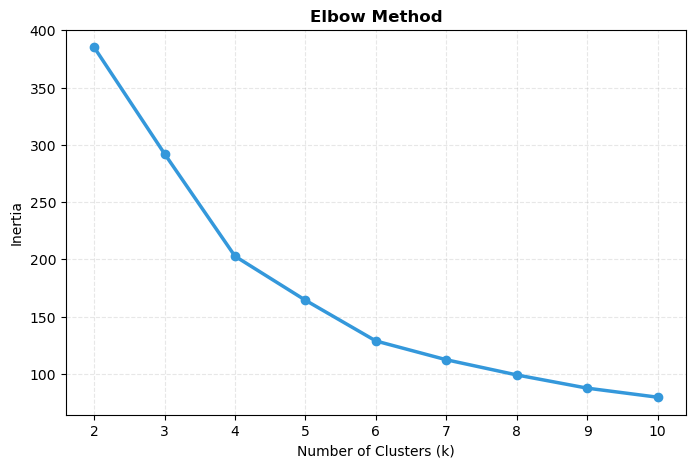

In [248]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='#3498db', linewidth=2.5)
plt.title('Elbow Method', fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(alpha=0.3, linestyle='--')
plt.show()

c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

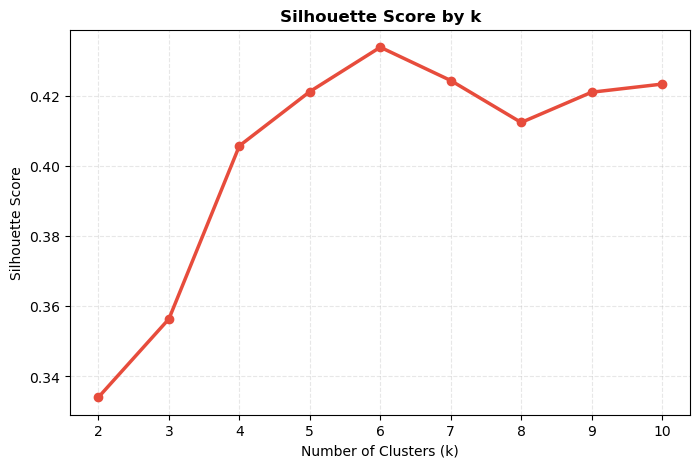

In [249]:
sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    sil_scores.append(silhouette_score(df_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o', color='#e74c3c', linewidth=2.5)
plt.title('Silhouette Score by k', fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(alpha=0.3, linestyle='--')
plt.show()

c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\3218592327.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster'] = kmeans.fit_predict(df_scaled)


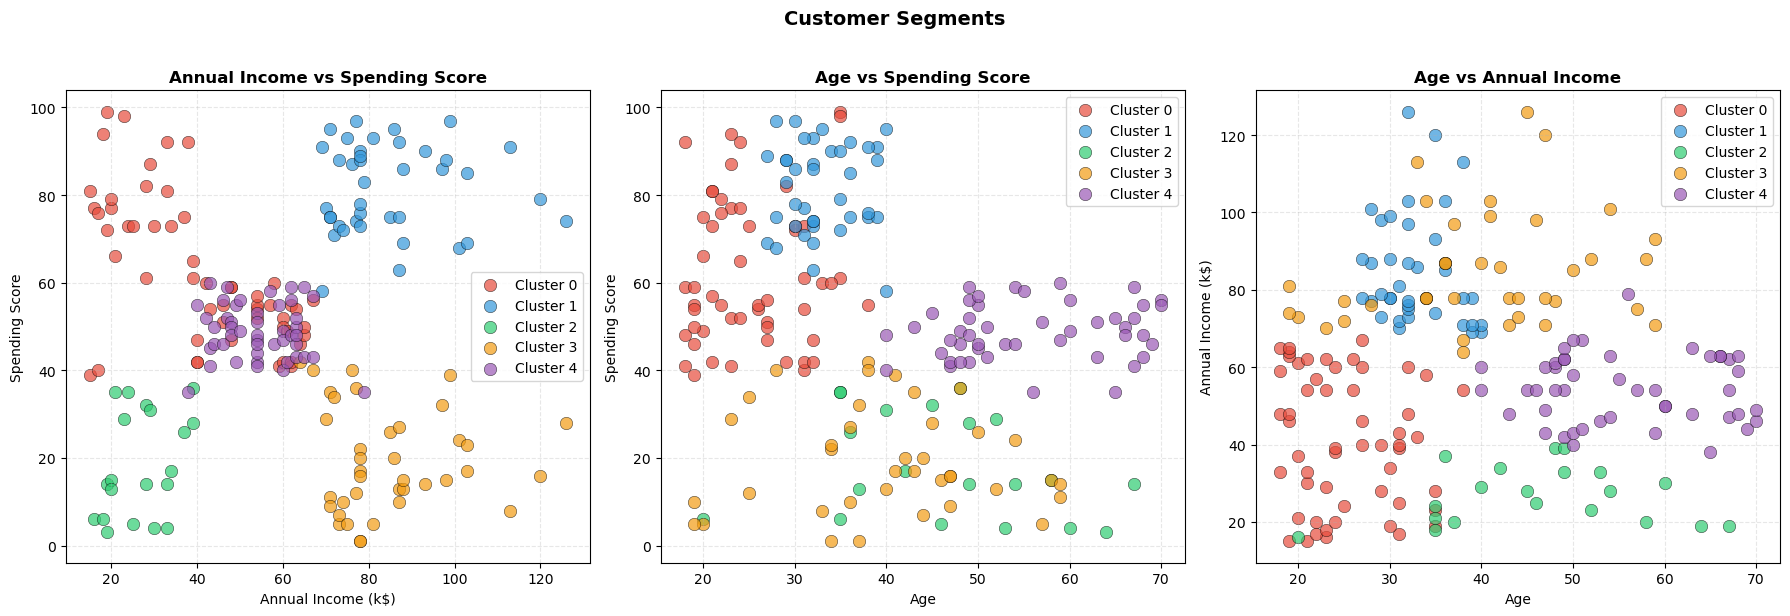

In [251]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(df_scaled)

palette = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
cluster_labels = {
    0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2',
    3: 'Cluster 3', 4: 'Cluster 4'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Annual Income vs Spending Score
for cluster in sorted(df_clean['Cluster'].unique()):
    subset = df_clean[df_clean['Cluster'] == cluster]
    axes[0].scatter(subset['Annual Income'], subset['Spending Score'],
                    label=cluster_labels[cluster], color=palette[cluster],
                    s=80, alpha=0.7, edgecolors='black', linewidth=0.4)
axes[0].set_title('Annual Income vs Spending Score', fontweight='bold')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')
axes[0].legend()
axes[0].grid(alpha=0.3, linestyle='--')

# 2. Age vs Spending Score
for cluster in sorted(df_clean['Cluster'].unique()):
    subset = df_clean[df_clean['Cluster'] == cluster]
    axes[1].scatter(subset['Age'], subset['Spending Score'],
                    label=cluster_labels[cluster], color=palette[cluster],
                    s=80, alpha=0.7, edgecolors='black', linewidth=0.4)
axes[1].set_title('Age vs Spending Score', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score')
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--')

# 3. Age vs Annual Income
for cluster in sorted(df_clean['Cluster'].unique()):
    subset = df_clean[df_clean['Cluster'] == cluster]
    axes[2].scatter(subset['Age'], subset['Annual Income'],
                    label=cluster_labels[cluster], color=palette[cluster],
                    s=80, alpha=0.7, edgecolors='black', linewidth=0.4)
axes[2].set_title('Age vs Annual Income', fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Annual Income (k$)')
axes[2].legend()
axes[2].grid(alpha=0.3, linestyle='--')

plt.suptitle('Customer Segments', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 4.2. Hierarchical Clustering

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\3719417842.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


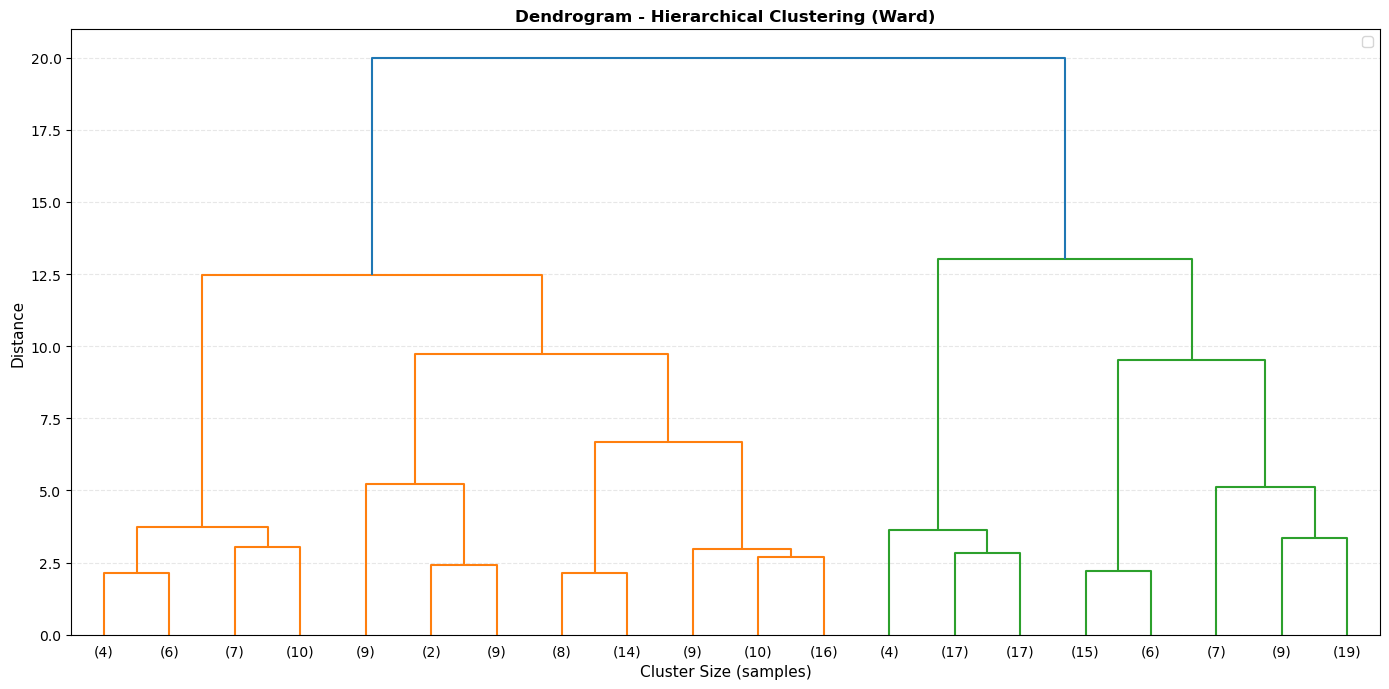

In [262]:
# Dendrogram with cut line
plt.figure(figsize=(14, 7))
linked = linkage(df_scaled, method='ward')
dendrogram(linked, truncate_mode='lastp', p=20, leaf_font_size=10)

plt.title('Dendrogram - Hierarchical Clustering (Ward)', fontsize=12, fontweight='bold')
plt.xlabel('Cluster Size (samples)', fontsize=11)
plt.ylabel('Distance', fontsize=11)
plt.legend()
plt.grid(alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.show()

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\3512490973.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster_HC'] = hc.fit_predict(df_scaled)


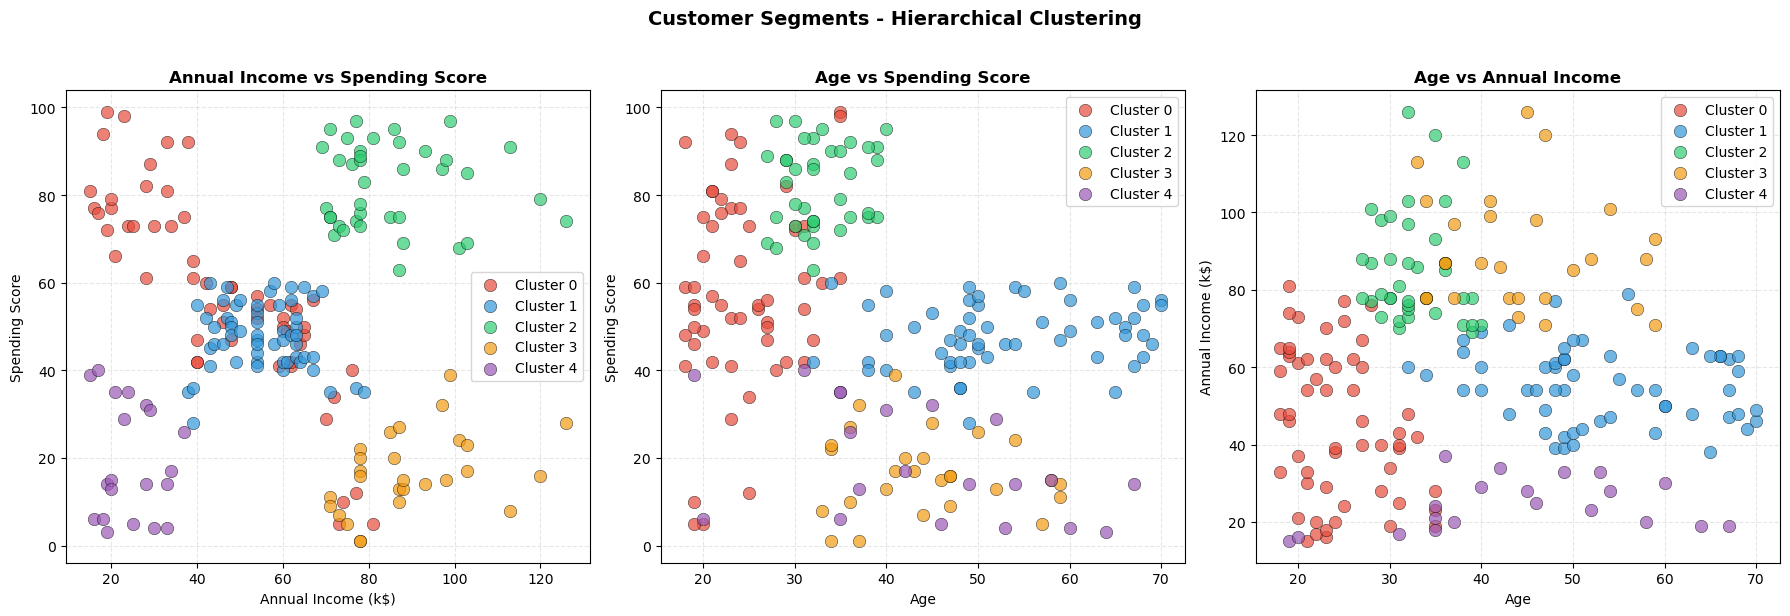

In [289]:

hc = AgglomerativeClustering(n_clusters=5)
df_clean['Cluster_HC'] = hc.fit_predict(df_scaled)

palette = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
cluster_labels = {
    0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3', 4: 'Cluster 4'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Annual Income vs Spending Score
for cluster in sorted(df_clean['Cluster_HC'].unique()):
    subset = df_clean[df_clean['Cluster_HC'] == cluster]
    axes[0].scatter(subset['Annual Income'], subset['Spending Score'],
                    label=cluster_labels[cluster], color=palette[cluster],
                    s=80, alpha=0.7, edgecolors='black', linewidth=0.4)
axes[0].set_title('Annual Income vs Spending Score', fontweight='bold')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')
axes[0].legend()
axes[0].grid(alpha=0.3, linestyle='--')

# 2. Age vs Spending Score
for cluster in sorted(df_clean['Cluster_HC'].unique()):
    subset = df_clean[df_clean['Cluster_HC'] == cluster]
    axes[1].scatter(subset['Age'], subset['Spending Score'],
                    label=cluster_labels[cluster], color=palette[cluster],
                    s=80, alpha=0.7, edgecolors='black', linewidth=0.4)
axes[1].set_title('Age vs Spending Score', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score')
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--')

# 3. Age vs Annual Income
for cluster in sorted(df_clean['Cluster_HC'].unique()):
    subset = df_clean[df_clean['Cluster_HC'] == cluster]
    axes[2].scatter(subset['Age'], subset['Annual Income'],
                    label=cluster_labels[cluster], color=palette[cluster],
                    s=80, alpha=0.7, edgecolors='black', linewidth=0.4)
axes[2].set_title('Age vs Annual Income', fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Annual Income (k$)')
axes[2].legend()
axes[2].grid(alpha=0.3, linestyle='--')

plt.suptitle('Customer Segments - Hierarchical Clustering', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 4.3 Gaussian Mixture Models

c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

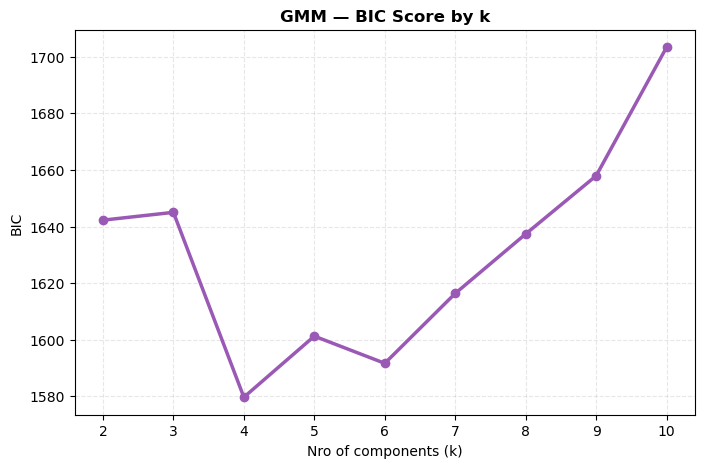

c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\882345437.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster_GMM'] = gmm.fit_predict(df_scaled)


In [290]:
# k from 2 to 10 with BIC (lower is better)
bic_scores = []
for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(df_scaled)
    bic_scores.append(gmm.bic(df_scaled))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), bic_scores, marker='o', color='#9B59B6', linewidth=2.5)
plt.title('GMM — BIC Score by k', fontweight='bold')
plt.xlabel('Nro of components (k)')
plt.ylabel('BIC')
plt.grid(alpha=0.3, linestyle='--')
plt.show()

# Fit final
gmm = GaussianMixture(n_components=4, random_state=42)
df_clean['Cluster_GMM'] = gmm.fit_predict(df_scaled)

c:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\4168729280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster_GMM'] = gmm.fit_predict(df_scaled)


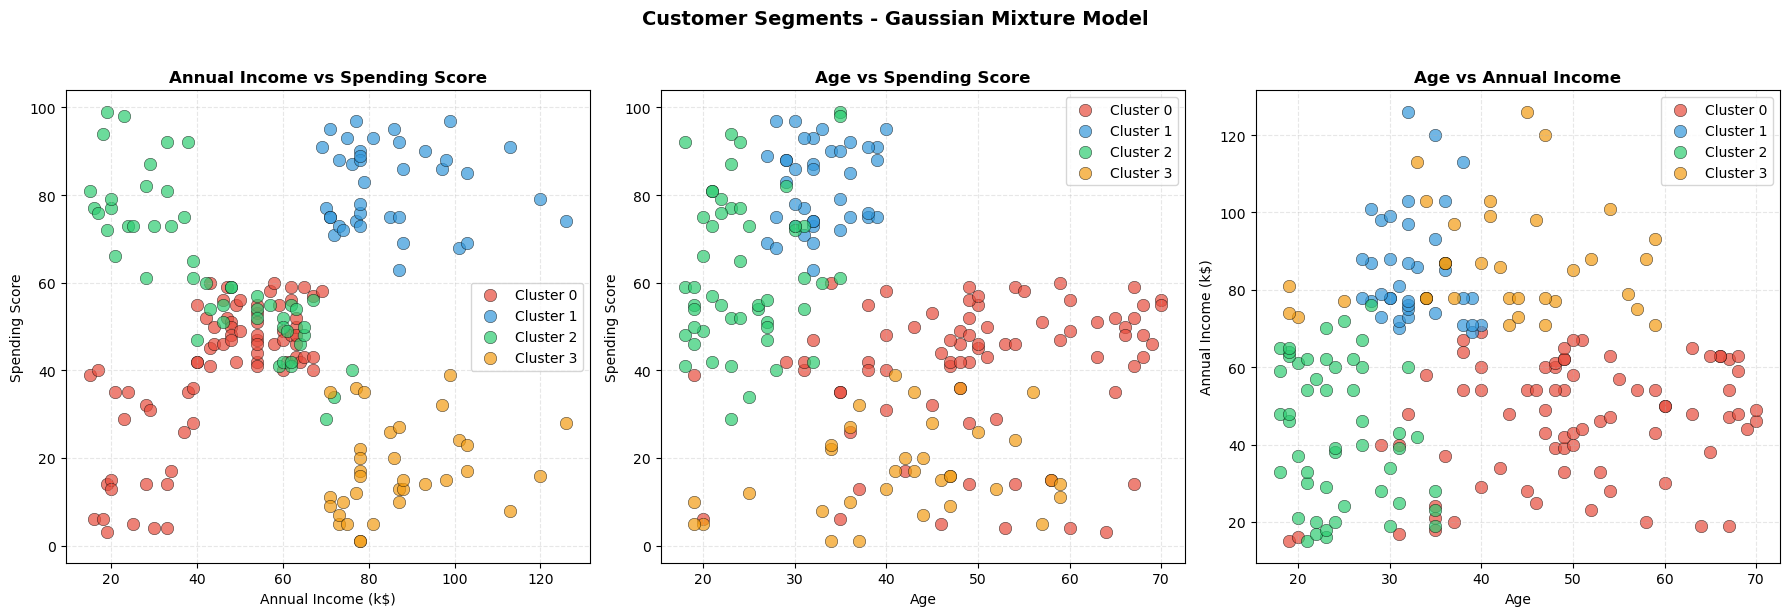

In [291]:
gmm = GaussianMixture(n_components=4, random_state=42)
df_clean['Cluster_GMM'] = gmm.fit_predict(df_scaled)

palette = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#34495E']
cluster_labels = {
    0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3', 4: 'Cluster 4', 5: 'Cluster 5'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Annual Income vs Spending Score
for cluster in sorted(df_clean['Cluster_GMM'].unique()):
    subset = df_clean[df_clean['Cluster_GMM'] == cluster]
    axes[0].scatter(subset['Annual Income'], subset['Spending Score'],
                    label=cluster_labels[cluster], color=palette[cluster],
                    s=80, alpha=0.7, edgecolors='black', linewidth=0.4)
axes[0].set_title('Annual Income vs Spending Score', fontweight='bold')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')
axes[0].legend()
axes[0].grid(alpha=0.3, linestyle='--')

# 2. Age vs Spending Score
for cluster in sorted(df_clean['Cluster_GMM'].unique()):
    subset = df_clean[df_clean['Cluster_GMM'] == cluster]
    axes[1].scatter(subset['Age'], subset['Spending Score'],
                    label=cluster_labels[cluster], color=palette[cluster],
                    s=80, alpha=0.7, edgecolors='black', linewidth=0.4)
axes[1].set_title('Age vs Spending Score', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score')
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--')

# 3. Age vs Annual Income
for cluster in sorted(df_clean['Cluster_GMM'].unique()):
    subset = df_clean[df_clean['Cluster_GMM'] == cluster]
    axes[2].scatter(subset['Age'], subset['Annual Income'],
                    label=cluster_labels[cluster], color=palette[cluster],
                    s=80, alpha=0.7, edgecolors='black', linewidth=0.4)
axes[2].set_title('Age vs Annual Income', fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Annual Income (k$)')
axes[2].legend()
axes[2].grid(alpha=0.3, linestyle='--')

plt.suptitle('Customer Segments - Gaussian Mixture Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [292]:
labels_kmeans = df_clean['Cluster']
labels_hc = df_clean['Cluster_HC']
labels_gmm = df_clean['Cluster_GMM']

for name, labels in [('KMeans', labels_kmeans), ('HC', labels_hc), ('GMM', labels_gmm)]:
    sil = silhouette_score(df_scaled, labels)
    db  = davies_bouldin_score(df_scaled, labels)
    ch  = calinski_harabasz_score(df_scaled, labels)
    print(f"{name} → Silhouette: {sil:.3f} | Davies-Bouldin: {db:.3f} | Calinski-Harabasz: {ch:.1f}")

KMeans → Silhouette: 0.421 | Davies-Bouldin: 0.865 | Calinski-Harabasz: 126.3
HC → Silhouette: 0.401 | Davies-Bouldin: 0.929 | Calinski-Harabasz: 106.7
GMM → Silhouette: 0.378 | Davies-Bouldin: 0.989 | Calinski-Harabasz: 108.0


In [257]:
df_clean['Cluster'].value_counts().sort_index()

Cluster
0    54
1    39
2    20
3    38
4    47
Name: count, dtype: int64

In [267]:
df_clean.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean().round(1)

,Age,Annual Income,Spending Score
Cluster,,,
0,25.2,41.1,62.2
1,32.9,84.8,81.5
2,46.2,26.8,18.4
3,40.1,84.8,19.4
4,55.6,54.4,48.9


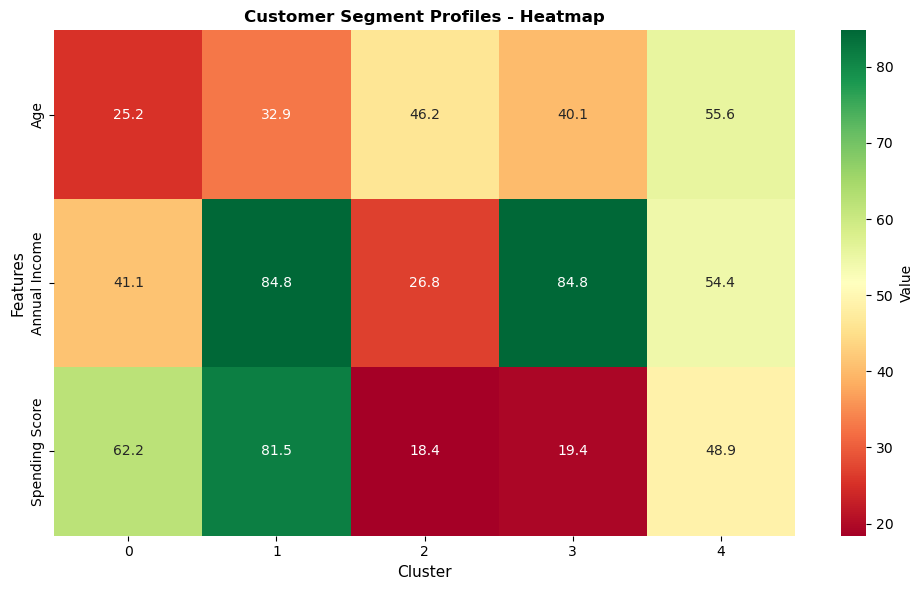

In [268]:
cluster_profile = df_clean.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean().round(1)

# Heatmap 
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile.T, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Value'})
plt.title('Customer Segment Profiles - Heatmap', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.tight_layout()
plt.show()

In [259]:
df_clean.groupby('Cluster')['Gender'].value_counts(normalize=True)

Cluster  Gender
0        Female    0.592593
         Male      0.407407
1        Female    0.564103
         Male      0.435897
2        Female    0.600000
         Male      0.400000
3        Female    0.500000
         Male      0.500000
4        Female    0.574468
         Male      0.425532
Name: proportion, dtype: float64

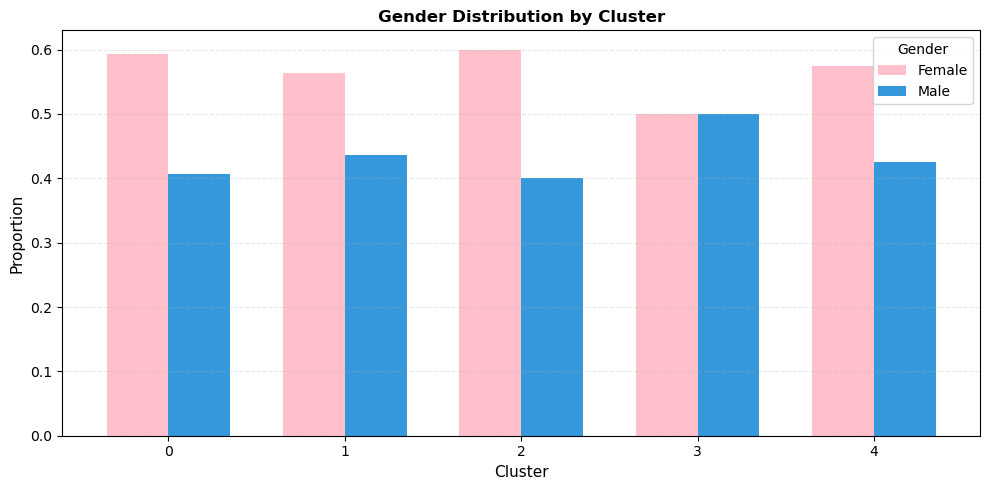

In [287]:
gender_dist = df_clean.groupby('Cluster')['Gender'].value_counts(normalize=True).unstack(fill_value=0)

gender_dist.plot(kind='bar', stacked=False, color=['pink', '#3498db'], width=0.7, figsize=(10, 5))
plt.title('Gender Distribution by Cluster', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=11)
plt.ylabel('Proportion', fontsize=11)
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.xticks(rotation=0)
plt.grid(alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.show()

In [281]:
cluster_names = {
    0: 'Young & Impulsive',
    1: 'Premium Customers',
    2: 'Budget Conscious',
    3: 'Untapped Potential',
    4: 'Mature & Balanced'
}

df_clean['Cluster_Name'] = df_clean['Cluster'].map(cluster_names)

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\1381830551.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster_Name'] = df_clean['Cluster'].map(cluster_names)


In [283]:
df_clean.groupby('Cluster_Name')[['AgeGroup', 'IncomeGroup', 'SpendingGroup']].agg(lambda x: x.value_counts().index[0])

,AgeGroup,IncomeGroup,SpendingGroup
Cluster_Name,,,
Budget Conscious,46-55,Low,Very Low
Mature & Balanced,46-55,Medium,Low
Premium Customers,26-35,High,Very High
Untapped Potential,36-45,High,Very Low
Young & Impulsive,18-25,Low,High


In [285]:
for cluster in df_clean['Cluster_Name'].unique():
    cluster_data = df_clean[df_clean['Cluster_Name'] == cluster]
    print(f"\n🔹 {cluster}")
    print(f"  AgeGroup: {cluster_data['AgeGroup'].value_counts().to_dict()}")
    print(f"  IncomeGroup: {cluster_data['IncomeGroup'].value_counts().to_dict()}")
    print(f"  SpendingGroup: {cluster_data['SpendingGroup'].value_counts().to_dict()}")


🔹 Young & Impulsive
  AgeGroup: {'18-25': 31, '26-35': 22, '36-45': 1, '46-55': 0, '56-70': 0}
  IncomeGroup: {'Low': 28, 'Medium': 26, 'High': 0, 'Very High': 0}
  SpendingGroup: {'High': 26, 'Low': 15, 'Very High': 13, 'Very Low': 0}

🔹 Budget Conscious
  AgeGroup: {'46-55': 7, '36-45': 5, '56-70': 4, '26-35': 3, '18-25': 1}
  IncomeGroup: {'Low': 20, 'Medium': 0, 'High': 0, 'Very High': 0}
  SpendingGroup: {'Very Low': 12, 'Low': 8, 'High': 0, 'Very High': 0}

🔹 Mature & Balanced
  AgeGroup: {'46-55': 22, '56-70': 21, '36-45': 4, '18-25': 0, '26-35': 0}
  IncomeGroup: {'Medium': 44, 'Low': 2, 'High': 1, 'Very High': 0}
  SpendingGroup: {'Low': 29, 'High': 18, 'Very Low': 0, 'Very High': 0}

🔹 Untapped Potential
  AgeGroup: {'36-45': 15, '46-55': 8, '18-25': 6, '26-35': 5, '56-70': 4}
  IncomeGroup: {'High': 29, 'Very High': 6, 'Medium': 3, 'Low': 0}
  SpendingGroup: {'Very Low': 26, 'Low': 12, 'High': 0, 'Very High': 0}

🔹 Premium Customers
  AgeGroup: {'26-35': 28, '36-45': 11, '1

In [279]:
markdown_text = """
## Customer Segment Profiles

| Cluster | Age (Mean) | Income (Mean) | Spending Score (Mean) | Segment Name | Description |
|---------|------------|--------|----------------|--------------|-------------|
| 0 | 25 | 41k | 62 | **Young & Impulsive** | Lower income but spend heavily |
| 1 | 33 | 85k | 82 | **Premium Customers** |High income and high spending |
| 2 | 46 | 27k | 18 | **Budget Conscious** | Low income and low spending, aware |
| 3 | 40 | 85k | 19 | **Untapped Potential** | High income but low spending — **enormous opportunity** |
| 4 | 56 | 54k | 49 | **Mature & Balanced** | Older, medium income, moderate spending |
"""

from IPython.display import Markdown
display(Markdown(markdown_text))


## Customer Segment Profiles

| Cluster | Age (Mean) | Income (Mean) | Spending Score (Mean) | Segment Name | Description |
|---------|------------|--------|----------------|--------------|-------------|
| 0 | 25 | 41k | 62 | **Young & Impulsive** | Lower income but spend heavily |
| 1 | 33 | 85k | 82 | **Premium Customers** |High income and high spending |
| 2 | 46 | 27k | 18 | **Budget Conscious** | Low income and low spending, aware |
| 3 | 40 | 85k | 19 | **Untapped Potential** | High income but low spending — **enormous opportunity** |
| 4 | 56 | 54k | 49 | **Mature & Balanced** | Older, medium income, moderate spending |


In [280]:
markdown_text = """
## Gender Distribution Insights

The gender pattern is consistent across clusters — **female customers dominate in almost every segment**, 
which aligns with the overall dataset composition.

The most notable finding is **Cluster 3 (Untapped Potential)** — the only cluster with a near **50/50 gender split**. 
This means the high-income, low-spending behaviour is not a male-driven phenomenon as one might assume, 
but rather an equal opportunity missed by the mall across both genders.

For the remaining clusters, the distribution follows the dataset's general pattern (~60% Female, ~40% Male), 
suggesting that **gender alone is not a strong differentiator between segments** — which further validates 
the decision to exclude it from the clustering model.
"""

from IPython.display import Markdown
display(Markdown(markdown_text))


## Gender Distribution Insights

The gender pattern is consistent across clusters — **female customers dominate in almost every segment**, 
which aligns with the overall dataset composition.

The most notable finding is **Cluster 3 (Untapped Potential)** — the only cluster with a near **50/50 gender split**. 
This means the high-income, low-spending behaviour is not a male-driven phenomenon as one might assume, 
but rather an equal opportunity missed by the mall across both genders.

For the remaining clusters, the distribution follows the dataset's general pattern (~60% Female, ~40% Male), 
suggesting that **gender alone is not a strong differentiator between segments** — which further validates 
the decision to exclude it from the clustering model.


In [286]:
markdown_text = """
## Customer Segment Profiles — Categorical Analysis

---

### 🔴 Young & Impulsive (Cluster 0)
- **Age:** Predominantly 18-25, with some 26-35
- **Income:** Low to Medium — limited financial power
- **Spending:** High to Very High — spend beyond their means
- **Insight:** Classic impulsive shoppers. High engagement but low income ceiling.

---

### 🔵 Premium Customers (Cluster 1)
- **Age:** Mostly 26-35, some 36-45
- **Income:** High to Very High
- **Spending:** Very High to High
- **Insight:** The golden segment. Young professionals at peak earning and spending. Priority target for loyalty programs.

---

### 🟢 Budget Conscious (Cluster 2)
- **Age:** Spread across 36-55, mostly 46-55
- **Income:** Almost exclusively Low
- **Spending:** Very Low to Low
- **Insight:** Financially constrained. Limited upside — focus on retention rather than upselling.

---

### 🟠 Untapped Potential (Cluster 3)
- **Age:** Mostly 36-45, spread across all groups
- **Income:** High to Very High
- **Spending:** Very Low to Low — spending far below their means
- **Insight:** The most valuable missed opportunity. High income but disengaged. Targeted campaigns and premium experiences could unlock significant revenue.

---

### 🟣 Mature & Balanced (Cluster 4)
- **Age:** Predominantly 46-70
- **Income:** Almost exclusively Medium
- **Spending:** Low to High — moderate and consistent
- **Insight:** Stable and predictable. Not high-value individually, but reliable. Good target for seasonal promotions.
"""

from IPython.display import Markdown
display(Markdown(markdown_text))


## Customer Segment Profiles — Categorical Analysis

---

### 🔴 Young & Impulsive (Cluster 0)
- **Age:** Predominantly 18-25, with some 26-35
- **Income:** Low to Medium — limited financial power
- **Spending:** High to Very High — spend beyond their means
- **Insight:** Classic impulsive shoppers. High engagement but low income ceiling.

---

### 🔵 Premium Customers (Cluster 1)
- **Age:** Mostly 26-35, some 36-45
- **Income:** High to Very High
- **Spending:** Very High to High
- **Insight:** The golden segment. Young professionals at peak earning and spending. Priority target for loyalty programs.

---

### 🟢 Budget Conscious (Cluster 2)
- **Age:** Spread across 36-55, mostly 46-55
- **Income:** Almost exclusively Low
- **Spending:** Very Low to Low
- **Insight:** Financially constrained. Limited upside — focus on retention rather than upselling.

---

### 🟠 Untapped Potential (Cluster 3)
- **Age:** Mostly 36-45, spread across all groups
- **Income:** High to Very High
- **Spending:** Very Low to Low — spending far below their means
- **Insight:** The most valuable missed opportunity. High income but disengaged. Targeted campaigns and premium experiences could unlock significant revenue.

---

### 🟣 Mature & Balanced (Cluster 4)
- **Age:** Predominantly 46-70
- **Income:** Almost exclusively Medium
- **Spending:** Low to High — moderate and consistent
- **Insight:** Stable and predictable. Not high-value individually, but reliable. Good target for seasonal promotions.


In [288]:
markdown_text = """
# Conclusions

This project aimed to segment mall customers based on demographic and behavioural data, 
using unsupervised machine learning techniques.

---

## Key Findings from EDA

- The dataset consists of **200 customers** aged 18 to 70, with annual incomes ranging from 15k to 137k.
- **Female customers dominate** the dataset (~56%), and consistently across all clusters.
- A key paradox was identified early on: **high income does not necessarily translate into high spending** — 
particularly in older age groups and male customers.

---

## Modelling

Three clustering algorithms were tested — **KMeans, Hierarchical Clustering, and Gaussian Mixture Models**.  
After comparing results visually and with three validation metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz), 
**KMeans with k=5 was selected** as the best performing model.

---

## Customer Segments

| Segment | Key Trait | Business Priority |
|---|---|---|
| **Young & Impulsive** | High spending, low income | Engage while young |
| **Premium Customers** | High income, high spending | Retain at all costs |
| **Budget Conscious** | Low income, low spending | Focus on retention |
| **Untapped Potential** | High income, low spending | Highest growth opportunity |
| **Mature & Balanced** | Medium income, moderate spending | Seasonal promotions |

---

## Business Recommendation

The **Untapped Potential** segment represents the most actionable insight of this analysis.  
These customers have the financial capacity of Premium Customers but the engagement levels of Budget Conscious ones.  
Targeted premium experiences, personalised campaigns, and loyalty incentives could significantly 
increase their spending score — directly impacting mall revenue.
"""

from IPython.display import Markdown
display(Markdown(markdown_text))


# Conclusions

This project aimed to segment mall customers based on demographic and behavioural data, 
using unsupervised machine learning techniques.

---

## Key Findings from EDA

- The dataset consists of **200 customers** aged 18 to 70, with annual incomes ranging from 15k to 137k.
- **Female customers dominate** the dataset (~56%), and consistently across all clusters.
- A key paradox was identified early on: **high income does not necessarily translate into high spending** — 
particularly in older age groups and male customers.

---

## Modelling

Three clustering algorithms were tested — **KMeans, Hierarchical Clustering, and Gaussian Mixture Models**.  
After comparing results visually and with three validation metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz), 
**KMeans with k=5 was selected** as the best performing model.

---

## Customer Segments

| Segment | Key Trait | Business Priority |
|---|---|---|
| **Young & Impulsive** | High spending, low income | Engage while young |
| **Premium Customers** | High income, high spending | Retain at all costs |
| **Budget Conscious** | Low income, low spending | Focus on retention |
| **Untapped Potential** | High income, low spending | Highest growth opportunity |
| **Mature & Balanced** | Medium income, moderate spending | Seasonal promotions |

---

## Business Recommendation

The **Untapped Potential** segment represents the most actionable insight of this analysis.  
These customers have the financial capacity of Premium Customers but the engagement levels of Budget Conscious ones.  
Targeted premium experiences, personalised campaigns, and loyalty incentives could significantly 
increase their spending score — directly impacting mall revenue.
